<a href="https://colab.research.google.com/github/AadiSharmaa/Google-Play-Store-Analysis-and-Prediction/blob/main/Google_Play_Store_Analysis_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Load the datasets
try:
    apps_df = pd.read_csv('googleplaystore.csv')
    reviews_df = pd.read_csv('googleplaystore_user_reviews.csv')
except FileNotFoundError:
    print("Make sure the 'googleplaystore.csv' and 'googleplaystore_user_reviews.csv' files are in the same directory.")
    exit()


1. Data Cleaning and Preprocessing

In [4]:
# Clean the 'googleplaystore.csv' dataset
def clean_apps_data(df):
    """Cleans the Google Play Store apps dataset."""
    # Drop rows with missing values in key columns
    df.dropna(subset=['Rating', 'Type', 'Content Rating', 'Current Ver', 'Android Ver'], inplace=True)

    # Convert 'Reviews' to numeric
    df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

    # Clean and convert 'Size' to numeric (in MB)
    df['Size'] = df['Size'].apply(lambda x: str(x).replace('M', '000') if 'M' in str(x) else str(x))
    df['Size'] = df['Size'].apply(lambda x: str(x).replace('k', '') if 'k' in str(x) else str(x))
    df['Size'] = df['Size'].apply(lambda x: str(x).replace('Varies with device', 'NaN') if 'Varies with device' in str(x) else str(x))
    df['Size'] = pd.to_numeric(df['Size'], errors='coerce')
    df['Size'] = df['Size'] / 1000 # Convert to MB
    # Fill missing sizes with the median
    df['Size'].fillna(df['Size'].median(), inplace=True)


    # Clean and convert 'Installs' to numeric
    df['Installs'] = df['Installs'].apply(lambda x: str(x).replace('+', '') if '+' in str(x) else str(x))
    df['Installs'] = df['Installs'].apply(lambda x: str(x).replace(',', '') if ',' in str(x) else str(x))
    df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

    # Clean and convert 'Price' to numeric
    df['Price'] = df['Price'].apply(lambda x: str(x).replace('$', '') if '$' in str(x) else str(x))
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

    return df

apps_df_cleaned = clean_apps_data(apps_df.copy())

# Clean the 'googleplaystore_user_reviews.csv' dataset
reviews_df.dropna(subset=['Translated_Review', 'Sentiment'], inplace=True)


/tmp/ipython-input-4-1492368781.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Size'].fillna(df['Size'].median(), inplace=True)


2. Exploratory Data Analysis (EDA)

Cleaned Apps DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 9360 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9360 non-null   object 
 1   Category        9360 non-null   object 
 2   Rating          9360 non-null   float64
 3   Reviews         9360 non-null   int64  
 4   Size            9360 non-null   float64
 5   Installs        9360 non-null   int64  
 6   Type            9360 non-null   object 
 7   Price           9360 non-null   float64
 8   Content Rating  9360 non-null   object 
 9   Genres          9360 non-null   object 
 10  Last Updated    9360 non-null   object 
 11  Current Ver     9360 non-null   object 
 12  Android Ver     9360 non-null   object 
dtypes: float64(3), int64(2), object(8)
memory usage: 1023.8+ KB

Cleaned User Reviews DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 37427 entries, 0 to 64230
Data columns (total

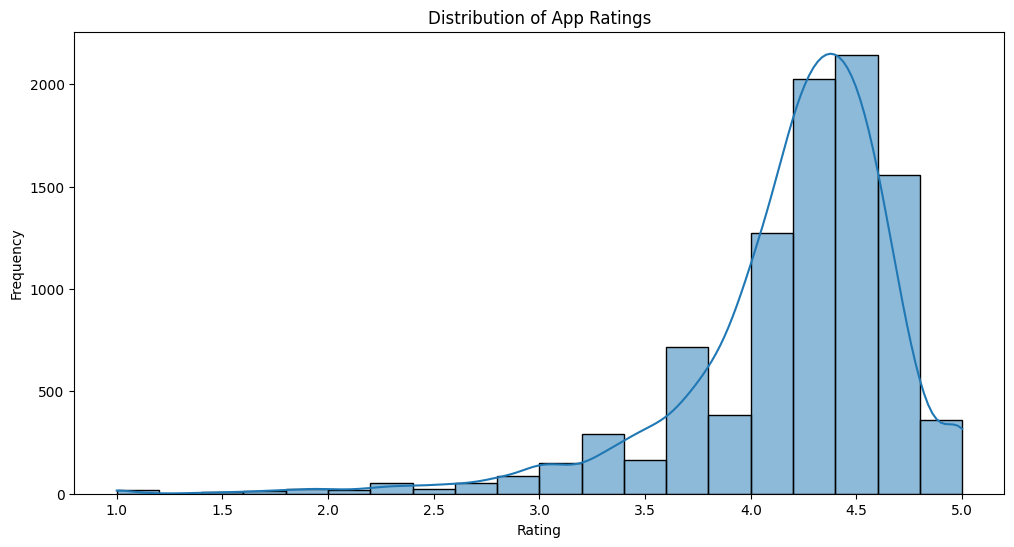

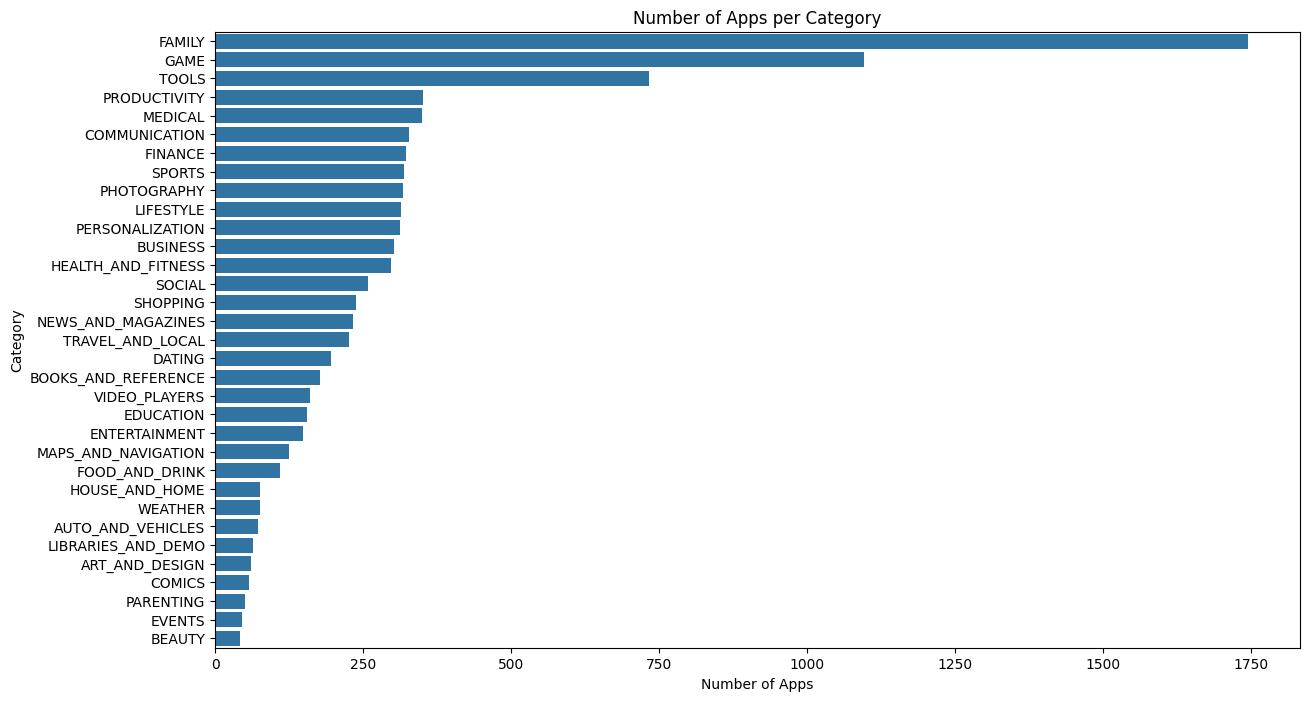

In [5]:
print("Cleaned Apps DataFrame Info:")
apps_df_cleaned.info()
print("\nCleaned User Reviews DataFrame Info:")
reviews_df.info()


# Plotting some insights
plt.figure(figsize=(12, 6))
sns.histplot(apps_df_cleaned['Rating'], bins=20, kde=True)
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(14, 8))
sns.countplot(y='Category', data=apps_df_cleaned, order=apps_df_cleaned['Category'].value_counts().index)
plt.title('Number of Apps per Category')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.show()


3. Sentiment Analysis

In [6]:
# Aggregate sentiment scores for each app
sentiment_agg = reviews_df.groupby('App')['Sentiment_Polarity'].mean().reset_index()
sentiment_agg.rename(columns={'Sentiment_Polarity': 'Average_Sentiment_Polarity'}, inplace=True)

4. Feature Engineering

In [7]:
# Merge the datasets
merged_df = pd.merge(apps_df_cleaned, sentiment_agg, on='App', how='left')
# Fill missing sentiment polarity with 0 (neutral)
merged_df['Average_Sentiment_Polarity'].fillna(0, inplace=True)

# Create a 'Success' feature
# Let's define success as having more than 1,000,000 installs and a rating of 4.1 or higher
merged_df['Success'] = ((merged_df['Installs'] >= 1000000) & (merged_df['Rating'] >= 4.1)).astype(int)


/tmp/ipython-input-7-2645592362.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df['Average_Sentiment_Polarity'].fillna(0, inplace=True)


5. Predictive Modeling


Model Accuracy: 0.90

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      1147
           1       0.87      0.88      0.88       725

    accuracy                           0.90      1872
   macro avg       0.90      0.90      0.90      1872
weighted avg       0.90      0.90      0.90      1872



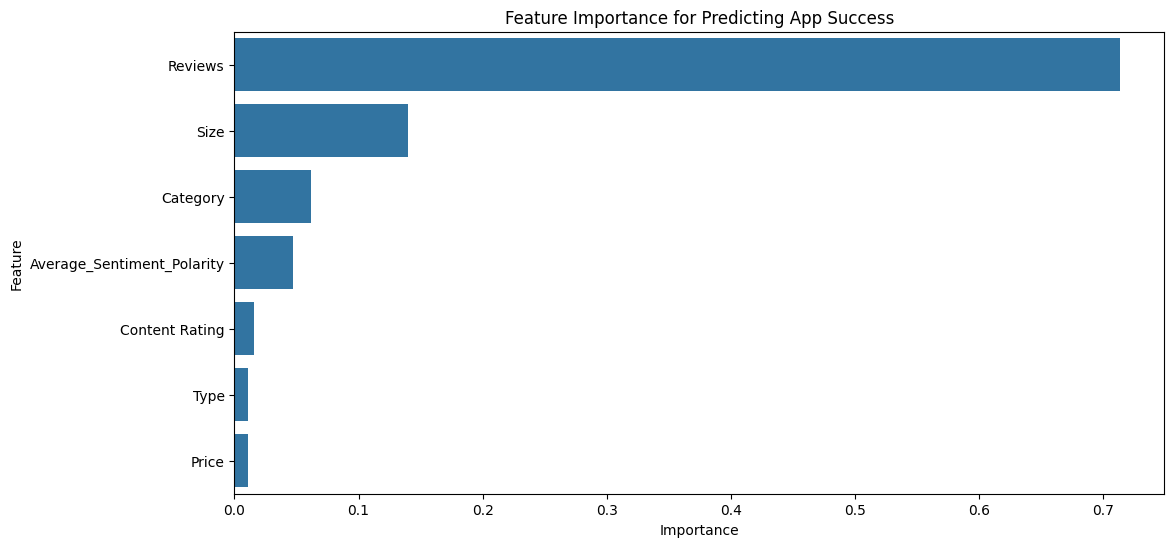

In [8]:
# Select features for the model
features = ['Category', 'Reviews', 'Size', 'Type', 'Price', 'Content Rating', 'Average_Sentiment_Polarity']
target = 'Success'

# Encode categorical features
label_encoders = {}
for column in ['Category', 'Type', 'Content Rating']:
    le = LabelEncoder()
    merged_df[column] = le.fit_transform(merged_df[column])
    label_encoders[column] = le

X = merged_df[features]
y = merged_df[target]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train a RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance
feature_importances = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importance for Predicting App Success')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()